In [1]:
# Support Vector Regression (SVR)
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
 


In [2]:
# Load dataset
dataset = pd.read_csv('Oilwell.csv')
X = dataset.iloc[:, [5,8]].values
y = dataset.iloc[:, -1].values.reshape(-1, 1)
 


In [3]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
# Feature scaling (required for SVR)
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_sc = sc_X.fit_transform(X_train)
X_test_sc  = sc_X.transform(X_test)
y_train_sc = sc_y.fit_transform(y_train).ravel()



In [5]:
# Train the model
regressor = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
regressor.fit(X_train_sc, y_train_sc)
 


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [6]:
# Predict and inverse-transform
y_pred_sc = regressor.predict(X_test_sc)
y_pred    = sc_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()
y_test    = y_test.ravel()


In [7]:
# Evaluate
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)


In [8]:
print(f"Kernel   : rbf")
print(f"C        : 100  |  Gamma: 0.1  |  Epsilon: 0.1")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")


Kernel   : rbf
C        : 100  |  Gamma: 0.1  |  Epsilon: 0.1
MSE      : 3.8382
RMSE     : 1.9591
R² Score : 0.9966


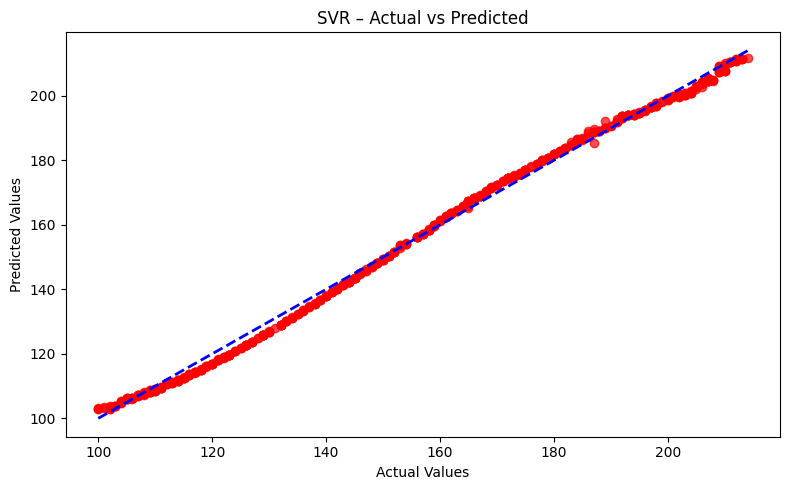

In [10]:
# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='red', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'b--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR – Actual vs Predicted")
plt.tight_layout()
plt.savefig("svr_plot.png", dpi=150)
plt.show()
